<a href="https://colab.research.google.com/github/sungheetha-it/AppsAndTools/blob/main/AC123.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Synthetic Dataset for Cryptography Lab

This synthetic dataset is designed to represent information that might require cryptographic protection. It includes mock user IDs, usernames, "passwords" (which can be used to demonstrate hashing), and simulated sensitive transaction data. This structure allows for exercises in:

*   **Hashing:** To protect passwords or verify data integrity.
*   **Encryption/Decryption:** To secure sensitive transaction amounts or personal data.
*   **Digital Signatures (conceptual):** To ensure authenticity and non-repudiation of transactions (though full implementation would require more advanced setup).

The dataset is small and illustrative, making it easy to manipulate and understand cryptographic principles.

In [4]:
import pandas as pd
import numpy as np

# Set a seed for reproducibility
np.random.seed(42)

# Generate synthetic data
num_records = 20

data = {
    'user_id': np.arange(1001, 1001 + num_records),
    'username': [f'user_{i}' for i in range(num_records)],
    'password_plaintext': [f'pass_{i}secret' for i in range(num_records)], # To be hashed in exercises
    'email': [f'user{i}@example.com' for i in range(num_records)],
    'transaction_id': [f'TRN{i:05d}' for i in range(num_records)],
    'transaction_amount': np.round(np.random.rand(num_records) * 1000 + 10, 2),
    'sensitive_note': [f'Private note for user {i}.' for i in range(num_records)],
    'timestamp': pd.to_datetime(pd.date_range(start='2023-01-01', periods=num_records, freq='h'))
}

df_crypto_lab = pd.DataFrame(data)

print(f"Generated {num_records} records for the cryptographic foundations lab dataset.")
display(df_crypto_lab.head())

Generated 20 records for the cryptographic foundations lab dataset.


,user_id,username,password_plaintext,email,transaction_id,transaction_amount,sensitive_note,timestamp
0,1001,user_0,pass_0secret,user0@example.com,TRN00000,384.54,Private note for user 0.,2023-01-01 00:00:00
1,1002,user_1,pass_1secret,user1@example.com,TRN00001,960.71,Private note for user 1.,2023-01-01 01:00:00
2,1003,user_2,pass_2secret,user2@example.com,TRN00002,741.99,Private note for user 2.,2023-01-01 02:00:00
3,1004,user_3,pass_3secret,user3@example.com,TRN00003,608.66,Private note for user 3.,2023-01-01 03:00:00
4,1005,user_4,pass_4secret,user4@example.com,TRN00004,166.02,Private note for user 4.,2023-01-01 04:00:00


### Encryption of 'transaction_amount' Column

For demonstrating encryption, we will use the `cryptography` library, which is a powerful and easy-to-use library for cryptographic recipes in Python. Specifically, we'll use `Fernet`, which is an implementation of symmetric encryption (the same key is used for both encryption and decryption).

**Key Management Note:** In a real-world application, securely storing and managing encryption keys is paramount. For this lab, we'll generate a key on-the-fly, but be aware that this key should never be hardcoded or exposed in a production environment.

In [6]:
!pip install cryptography

In [7]:
from cryptography.fernet import Fernet

# Generate a Fernet key
# This key should be securely stored and never exposed in a real application.
key = Fernet.generate_key()
fernet = Fernet(key)

print("Generated Fernet Key (for demonstration):", key.decode())
print("\nEncrypting the 'transaction_amount' column...")

# Encrypt the 'transaction_amount' column
# First, convert the numeric values to strings, then to bytes for encryption
df_crypto_lab['encrypted_transaction_amount'] = df_crypto_lab['transaction_amount'].astype(str).apply(lambda x: fernet.encrypt(x.encode()))

print("Encryption complete. Displaying the original and encrypted amounts.")
display(df_crypto_lab[['transaction_amount', 'encrypted_transaction_amount']].head())

Generated Fernet Key (for demonstration): WxM122NdTySlj4EjiEpWVb9ciZfGc7M1_7P-fuAgMfw=

Encrypting the 'transaction_amount' column...
Encryption complete. Displaying the original and encrypted amounts.


,transaction_amount,encrypted_transaction_amount
0,384.54,b'gAAAAABqfW5rwKEsHZ5uiBfePzMcY_wPx86EqyMTu8tk...
1,960.71,b'gAAAAABqfW5rk8DHm5Rx-t76nB2dQ8348MBLgGA3d6cX...
2,741.99,b'gAAAAABqfW5rdWpHA3KRaPHqKIuZYhvTv52N9XA0xnRc...
3,608.66,b'gAAAAABqfW5r_1NVi7YWnhsHAnmx9j4o6obfls-qZF2V...
4,166.02,b'gAAAAABqfW5rpMCHqk8KuDEs_dICxmAoAB5gJa2eyG6U...


As you can see, the `encrypted_transaction_amount` column now contains seemingly random bytes, which is the encrypted form of the original transaction amounts. This data is unintelligible without the correct `Fernet` key.

To complete the demonstration, you would typically also show how to decrypt this data using the same key.

### Decryption of 'encrypted_transaction_amount' Column

Now that we have encrypted the `transaction_amount`, let's demonstrate how to decrypt it back to its original form. We will use the *same* `Fernet` key that was used for encryption. This highlights the symmetric nature of Fernet encryption.

In [8]:
# Decrypt the 'encrypted_transaction_amount' column
# We use the same 'fernet' instance created with the original key
df_crypto_lab['decrypted_transaction_amount'] = df_crypto_lab['encrypted_transaction_amount'].apply(lambda x: fernet.decrypt(x).decode())

# Convert decrypted column back to numeric type for comparison
df_crypto_lab['decrypted_transaction_amount'] = df_crypto_lab['decrypted_transaction_amount'].astype(float)

print("Decryption complete. Displaying original, encrypted, and decrypted amounts.")
display(df_crypto_lab[['transaction_amount', 'encrypted_transaction_amount', 'decrypted_transaction_amount']].head())

# Verify if original and decrypted amounts match
comparison_result = (df_crypto_lab['transaction_amount'] == df_crypto_lab['decrypted_transaction_amount']).all()
print(f"\nDo original and decrypted transaction amounts match? {comparison_result}")

Decryption complete. Displaying original, encrypted, and decrypted amounts.


,transaction_amount,encrypted_transaction_amount,decrypted_transaction_amount
0,384.54,b'gAAAAABqfW5rwKEsHZ5uiBfePzMcY_wPx86EqyMTu8tk...,384.54
1,960.71,b'gAAAAABqfW5rk8DHm5Rx-t76nB2dQ8348MBLgGA3d6cX...,960.71
2,741.99,b'gAAAAABqfW5rdWpHA3KRaPHqKIuZYhvTv52N9XA0xnRc...,741.99
3,608.66,b'gAAAAABqfW5r_1NVi7YWnhsHAnmx9j4o6obfls-qZF2V...,608.66
4,166.02,b'gAAAAABqfW5rpMCHqk8KuDEs_dICxmAoAB5gJa2eyG6U...,166.02



Do original and decrypted transaction amounts match? True


### Data Visualization: Transaction Amount Over Time

To understand the distribution and potential trends in our synthetic `transaction_amount` data, let's plot it against the `timestamp`. This can help in identifying any patterns, even in a small dataset.

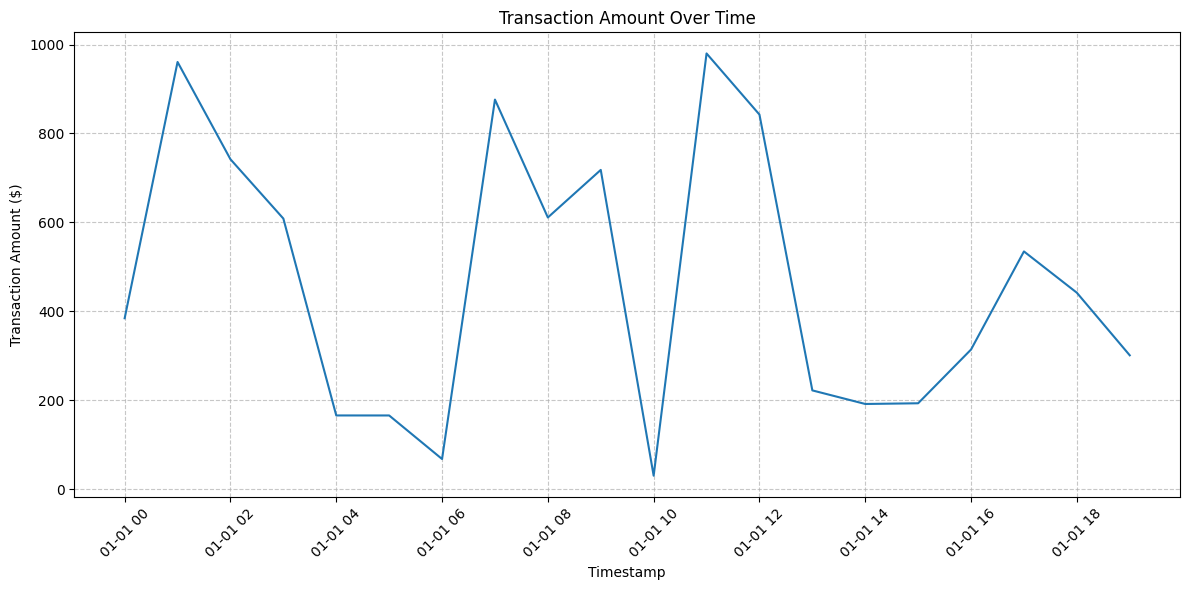

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='timestamp', y='transaction_amount', data=df_crypto_lab)
plt.title('Transaction Amount Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Transaction Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Simple Prediction Demonstration

For a cryptographic foundations lab, the primary focus is not on building complex predictive models, but rather on understanding how cryptographic operations affect data utility. However, we can demonstrate a very basic prediction task. Let's try to predict the `transaction_amount` based on the `timestamp` using a simple linear regression.

**Important Note:** Predictive models cannot operate directly on encrypted data. Data must be decrypted before it can be used for analysis or prediction. If encrypted data is used, the model would find no meaningful patterns, as the encrypted values are essentially random.

Mean Squared Error (MSE) for predicting transaction_amount: 67220.72


,Actual,Predicted
0,384.54,583.160991
17,534.76,387.100950
15,193.40,410.166837
1,960.71,571.628048
8,611.12,490.897442
5,165.99,525.496273


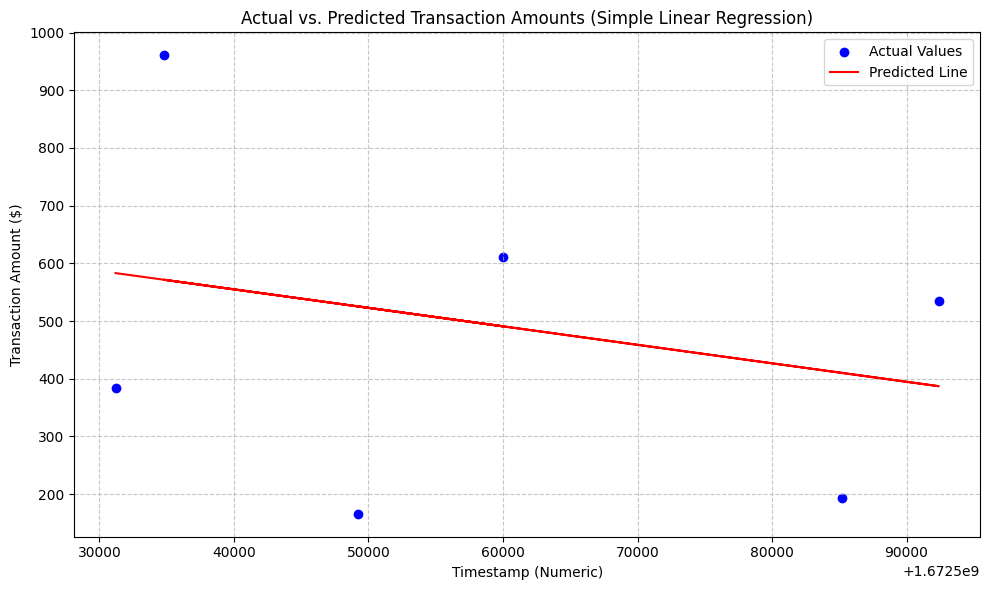

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Convert timestamp to numerical feature for regression
# Using Unix timestamp (seconds since epoch) as a simple numerical representation
df_crypto_lab['timestamp_numeric'] = df_crypto_lab['timestamp'].apply(lambda x: x.timestamp())

# Prepare data for prediction
X = df_crypto_lab[['timestamp_numeric']]
y = df_crypto_lab['transaction_amount']

# Split data into training and testing sets (for demonstration, small dataset)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE) for predicting transaction_amount: {mse:.2f}")

# Display some predictions vs actual values
prediction_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(prediction_df)

# Plot actual vs predicted (for context)
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Values')
plt.plot(X_test, y_pred, color='red', label='Predicted Line')
plt.title('Actual vs. Predicted Transaction Amounts (Simple Linear Regression)')
plt.xlabel('Timestamp (Numeric)')
plt.ylabel('Transaction Amount ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Generated 20 records for the cryptographic foundations lab dataset.


,user_id,username,password_plaintext,email,transaction_id,transaction_amount,sensitive_note,timestamp
0,1001,user_0,pass_0secret,user0@example.com,TRN00000,384.54,Private note for user 0.,2023-01-01 00:00:00
1,1002,user_1,pass_1secret,user1@example.com,TRN00001,960.71,Private note for user 1.,2023-01-01 01:00:00
2,1003,user_2,pass_2secret,user2@example.com,TRN00002,741.99,Private note for user 2.,2023-01-01 02:00:00
3,1004,user_3,pass_3secret,user3@example.com,TRN00003,608.66,Private note for user 3.,2023-01-01 03:00:00
4,1005,user_4,pass_4secret,user4@example.com,TRN00004,166.02,Private note for user 4.,2023-01-01 04:00:00


Generated Fernet Key (for demonstration): b2kS8c7zz7QfUq7Fm8We2GDXfxOxcFTbWetnrC2fw4g=

Encrypting the 'transaction_amount' column...
Encryption complete. Displaying the original and encrypted amounts.


,transaction_amount,encrypted_transaction_amount
0,384.54,b'gAAAAABqfXIuWho8pPKs75QiKtQBsACr03j9pANqCts1...
1,960.71,b'gAAAAABqfXIuPwB7xx4Z0DIW6ppt29TKV31aFWugr4bE...
2,741.99,b'gAAAAABqfXIuZsmXnyCotpgPLSeS6iIyRgokwBu4yB1V...
3,608.66,b'gAAAAABqfXIu8rq55MLlHeDjb46n8DT2kva8dCoz6h2y...
4,166.02,b'gAAAAABqfXIu3hEFhogDnIox0og2bZ3HXunh2wnlFmXK...


Decryption complete. Displaying original, encrypted, and decrypted amounts.


,transaction_amount,encrypted_transaction_amount,decrypted_transaction_amount
0,384.54,b'gAAAAABqfXIuWho8pPKs75QiKtQBsACr03j9pANqCts1...,384.54
1,960.71,b'gAAAAABqfXIuPwB7xx4Z0DIW6ppt29TKV31aFWugr4bE...,960.71
2,741.99,b'gAAAAABqfXIuZsmXnyCotpgPLSeS6iIyRgokwBu4yB1V...,741.99
3,608.66,b'gAAAAABqfXIu8rq55MLlHeDjb46n8DT2kva8dCoz6h2y...,608.66
4,166.02,b'gAAAAABqfXIu3hEFhogDnIox0og2bZ3HXunh2wnlFmXK...,166.02



Do original and decrypted transaction amounts match? True


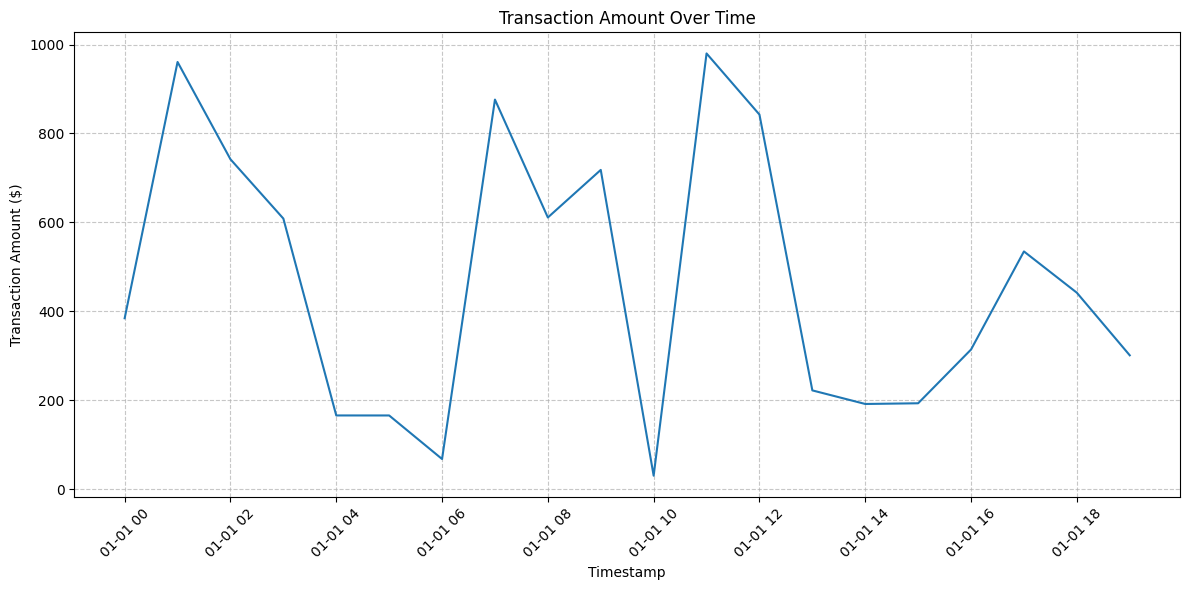

Mean Squared Error (MSE) for predicting transaction_amount: 67220.72


,Actual,Predicted
0,384.54,583.160991
17,534.76,387.100950
15,193.40,410.166837
1,960.71,571.628048
8,611.12,490.897442
5,165.99,525.496273


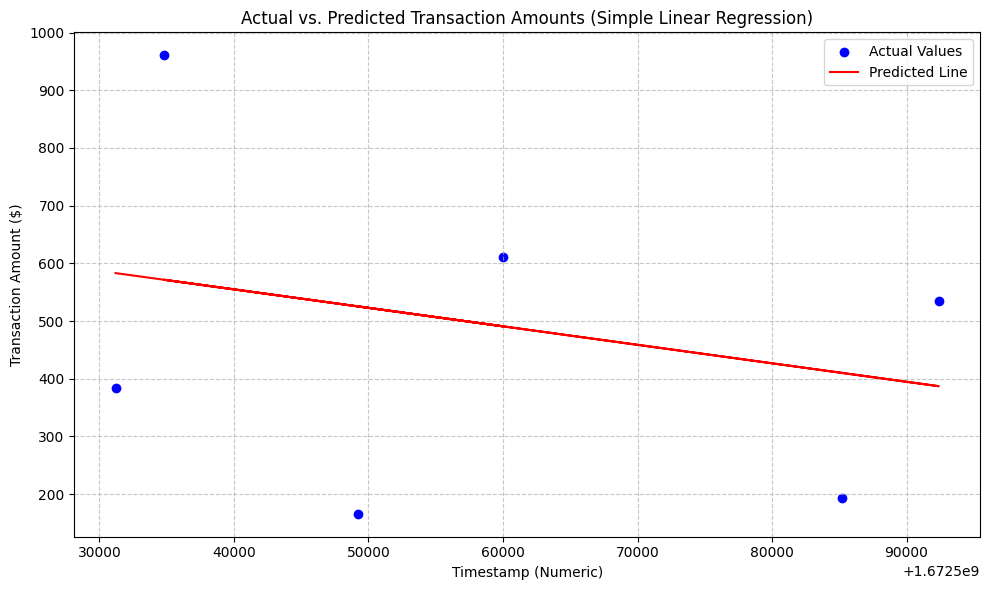

In [11]:
# ### Synthetic Dataset for Cryptography Lab
# # This synthetic dataset is designed to represent information that might require cryptographic protection.
# # It includes mock user IDs, usernames, "passwords" (which can be used to demonstrate hashing),
# # and simulated sensitive transaction data. This structure allows for exercises in:
# # *   **Hashing:** To protect passwords or verify data integrity.
# # *   **Encryption/Decryption:** To secure sensitive transaction amounts or personal data.
# # *   **Digital Signatures (conceptual):** To ensure authenticity and non-repudiation of transactions
# #     (though full implementation would require more advanced setup).
# # The dataset is small and illustrative, making it easy to manipulate and understand cryptographic principles.

import pandas as pd
import numpy as np

# Set a seed for reproducibility
np.random.seed(42)

# Generate synthetic data
num_records = 20

data = {
    'user_id': np.arange(1001, 1001 + num_records),
    'username': [f'user_{i}' for i in range(num_records)],
    'password_plaintext': [f'pass_{i}secret' for i in range(num_records)], # To be hashed in exercises
    'email': [f'user{i}@example.com' for i in range(num_records)],
    'transaction_id': [f'TRN{i:05d}' for i in range(num_records)],
    'transaction_amount': np.round(np.random.rand(num_records) * 1000 + 10, 2),
    'sensitive_note': [f'Private note for user {i}.' for i in range(num_records)],
    'timestamp': pd.to_datetime(pd.date_range(start='2023-01-01', periods=num_records, freq='h'))
}

df_crypto_lab = pd.DataFrame(data)

print(f"Generated {num_records} records for the cryptographic foundations lab dataset.")
display(df_crypto_lab.head())

# ### Encryption of 'transaction_amount' Column
# # For demonstrating encryption, we will use the `cryptography` library, which is a powerful
# # and easy-to-use library for cryptographic recipes in Python. Specifically, we'll use `Fernet`,
# # which is an implementation of symmetric encryption (the same key is used for both encryption and decryption).
# # **Key Management Note:** In a real-world application, securely storing and managing encryption keys is paramount.
# # For this lab, we'll generate a key on-the-fly, but be aware that this key should never be hardcoded or exposed in a production environment.

!pip install cryptography --quiet

from cryptography.fernet import Fernet

# Generate a Fernet key
# This key should be securely stored and never exposed in a real application.
key = Fernet.generate_key()
fernet = Fernet(key)

print("Generated Fernet Key (for demonstration):", key.decode())
print("\nEncrypting the 'transaction_amount' column...")

# Encrypt the 'transaction_amount' column
# First, convert the numeric values to strings, then to bytes for encryption
df_crypto_lab['encrypted_transaction_amount'] = df_crypto_lab['transaction_amount'].astype(str).apply(lambda x: fernet.encrypt(x.encode()))

print("Encryption complete. Displaying the original and encrypted amounts.")
display(df_crypto_lab[['transaction_amount', 'encrypted_transaction_amount']].head())

# # As you can see, the `encrypted_transaction_amount` column now contains seemingly random bytes,
# # which is the encrypted form of the original transaction amounts. This data is unintelligible
# # without the correct `Fernet` key.
# # To complete the demonstration, you would typically also show how to decrypt this data using the same key.

# ### Decryption of 'encrypted_transaction_amount' Column
# # Now that we have encrypted the `transaction_amount`, let's demonstrate how to decrypt it back to its original form.
# # We will use the *same* `Fernet` key that was used for encryption. This highlights the symmetric nature of Fernet encryption.

# Decrypt the 'encrypted_transaction_amount' column
# We use the same 'fernet' instance created with the original key
df_crypto_lab['decrypted_transaction_amount'] = df_crypto_lab['encrypted_transaction_amount'].apply(lambda x: fernet.decrypt(x).decode())

# Convert decrypted column back to numeric type for comparison
df_crypto_lab['decrypted_transaction_amount'] = df_crypto_lab['decrypted_transaction_amount'].astype(float)

print("Decryption complete. Displaying original, encrypted, and decrypted amounts.")
display(df_crypto_lab[['transaction_amount', 'encrypted_transaction_amount', 'decrypted_transaction_amount']].head())

# Verify if original and decrypted amounts match
comparison_result = (df_crypto_lab['transaction_amount'] == df_crypto_lab['decrypted_transaction_amount']).all()
print(f"\nDo original and decrypted transaction amounts match? {comparison_result}")

# ### Data Visualization: Transaction Amount Over Time
# # To understand the distribution and potential trends in our synthetic `transaction_amount` data,
# # let's plot it against the `timestamp`. This can help in identifying any patterns, even in a small dataset.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='timestamp', y='transaction_amount', data=df_crypto_lab)
plt.title('Transaction Amount Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Transaction Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ### Simple Prediction Demonstration
# # For a cryptographic foundations lab, the primary focus is not on building complex predictive models,
# # but rather on understanding how cryptographic operations affect data utility. However, we can demonstrate
# # a very basic prediction task. Let's try to predict the `transaction_amount` based on the `timestamp`
# # using a simple linear regression.
# # **Important Note:** Predictive models cannot operate directly on encrypted data. Data must be decrypted
# # before it can be used for analysis or prediction. If encrypted data is used, the model would find no meaningful
# # patterns, as the encrypted values are essentially random.

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Convert timestamp to numerical feature for regression
# Using Unix timestamp (seconds since epoch) as a simple numerical representation
df_crypto_lab['timestamp_numeric'] = df_crypto_lab['timestamp'].apply(lambda x: x.timestamp())

# Prepare data for prediction
X = df_crypto_lab[['timestamp_numeric']]
y = df_crypto_lab['transaction_amount']

# Split data into training and testing sets (for demonstration, small dataset)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE) for predicting transaction_amount: {mse:.2f}")

# Display some predictions vs actual values
prediction_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(prediction_df)

# Plot actual vs predicted (for context)
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Values')
plt.plot(X_test, y_pred, color='red', label='Predicted Line')
plt.title('Actual vs. Predicted Transaction Amounts (Simple Linear Regression)')
plt.xlabel('Timestamp (Numeric)')
plt.ylabel('Transaction Amount ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()